In [1]:
# ================================
# TASK 2: CUSTOMER SEGMENTATION USING K-MEANS
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [3]:

# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_csv(r"E:\it\Data_Science_&_Analytics\phase 2\2nd Task\Mall Customers.csv")

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


DATASET OVERVIEW

Shape: (200, 7)

Columns:
['CustomerID', 'Gender', 'Age', 'Education ', 'Marital Status', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 Rows:


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40



Missing Values:
CustomerID                0
Gender                    0
Age                       0
Education                 0
Marital Status            0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [4]:

# -----------------------------
# BASIC EDA
# -----------------------------
print("\nSummary Statistics:")
display(df.describe(include='all'))



Summary Statistics:


,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200,200,200.000000,200.000000
unique,NaN,2,NaN,7,4,NaN,NaN
top,NaN,F,NaN,Graduate,Married,NaN,NaN
freq,NaN,112,NaN,67,112,NaN,NaN
mean,100.500000,NaN,38.850000,NaN,NaN,60.560000,50.200000
std,57.879185,NaN,13.969007,NaN,NaN,26.264721,25.823522
min,1.000000,NaN,18.000000,NaN,NaN,15.000000,1.000000
25%,50.750000,NaN,28.750000,NaN,NaN,41.500000,34.750000
50%,100.500000,NaN,36.000000,NaN,NaN,61.500000,50.000000
75%,150.250000,NaN,49.000000,NaN,NaN,78.000000,73.000000


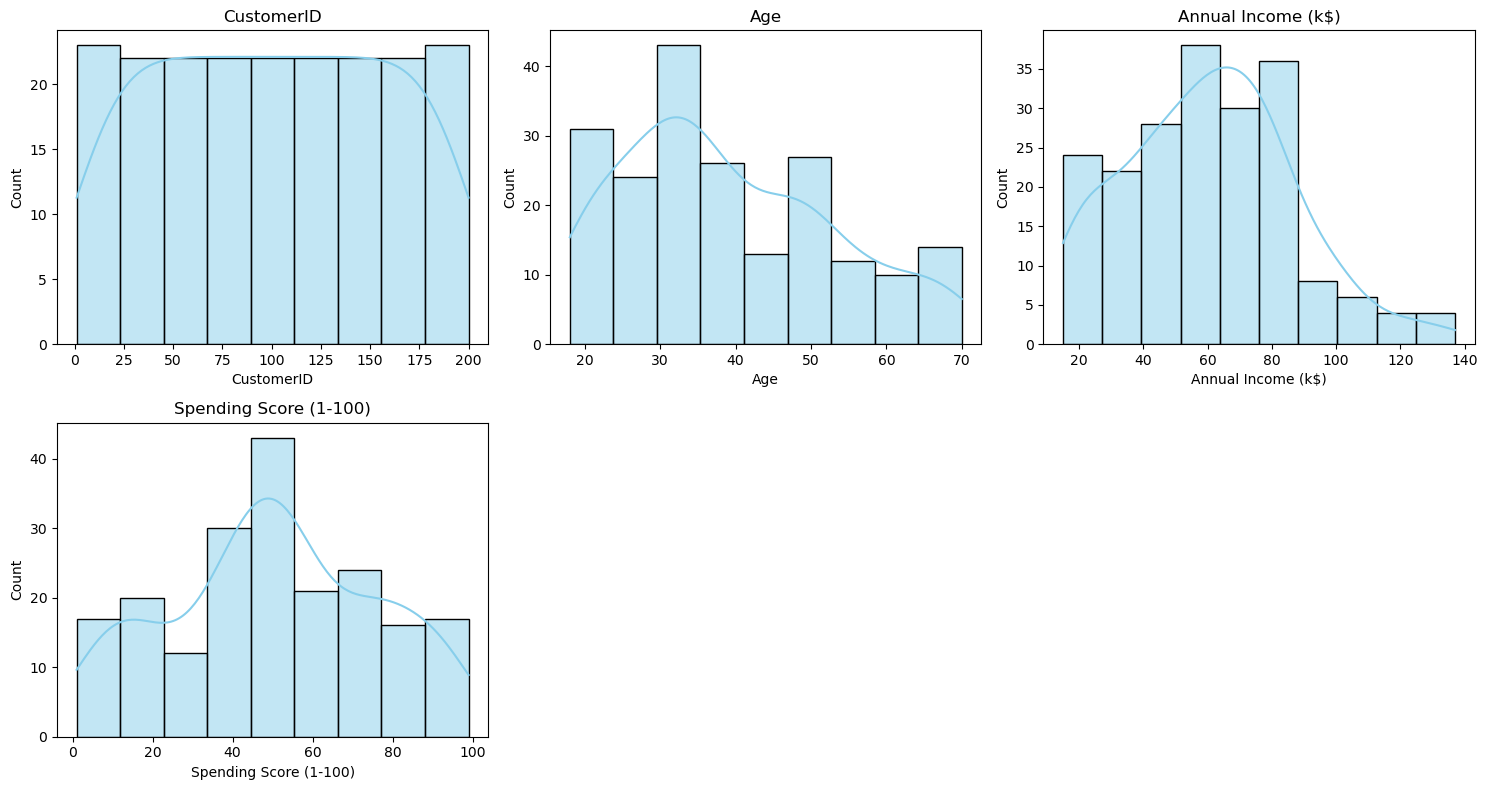

In [5]:

# Histograms
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))
for i,col in enumerate(numeric_cols,1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()


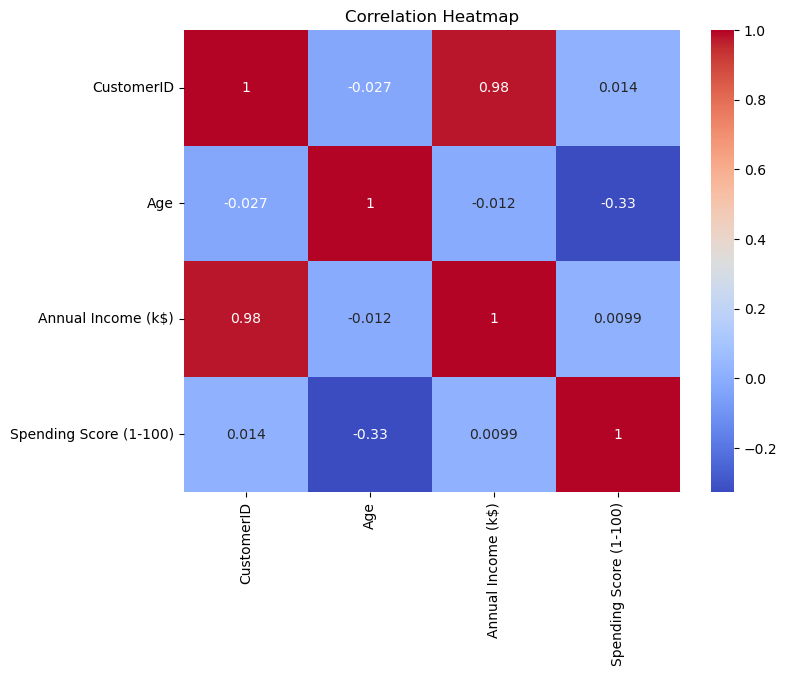

In [6]:

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [7]:

# -----------------------------
# DATA PREPROCESSING
# -----------------------------
data = df.copy()

# Fill missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

# Encode categorical columns
le = LabelEncoder()

categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Remove CustomerID from clustering
if 'CustomerID' in data.columns:
    X = data.drop('CustomerID', axis=1)
else:
    X = data.copy()

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

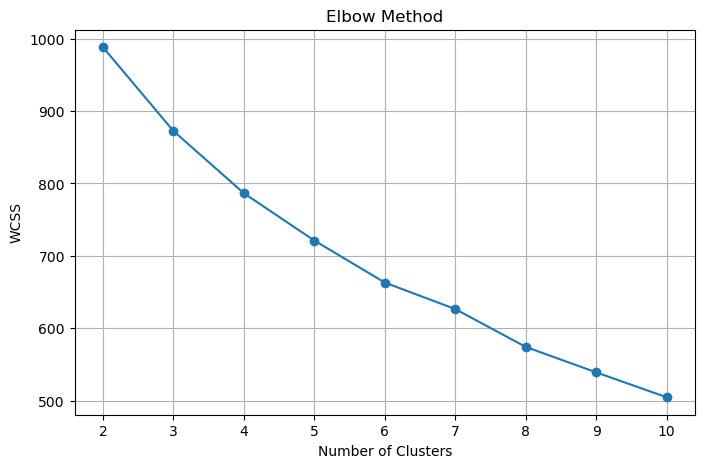

In [8]:

# -----------------------------
# ELBOW METHOD
# -----------------------------
wcss = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


In [9]:

# -----------------------------
# FIND BEST K USING SILHOUETTE
# -----------------------------
best_k = 2
best_score = -1

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nBest Number of Clusters = {best_k}")
print(f"Silhouette Score = {best_score:.3f}")


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window


Best Number of Clusters = 10
Silhouette Score = 0.190


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:

# -----------------------------
# FINAL K-MEANS MODEL
# -----------------------------
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


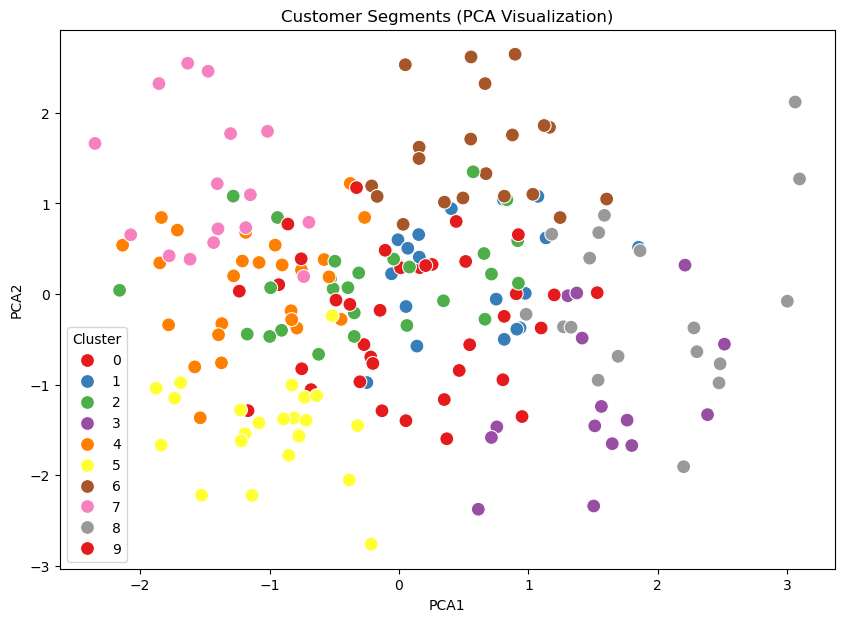

In [11]:

# -----------------------------
# PCA VISUALIZATION
# -----------------------------
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PCA1": pca_components[:,0],
    "PCA2": pca_components[:,1],
    "Cluster": clusters
})

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segments (PCA Visualization)")
plt.show()




CLUSTER PROFILE


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,78.600000,28.100000,49.700000,69.100000
1,64.631579,46.894737,45.526316,37.421053
2,79.615385,31.153846,51.461538,47.423077
3,166.466667,42.333333,88.733333,12.200000
4,79.346154,29.461538,50.730769,57.346154
5,170.260870,33.130435,92.217391,85.000000
6,66.250000,52.150000,46.450000,43.150000
7,92.235294,26.882353,55.352941,67.470588
8,65.388889,62.444444,45.666667,39.333333



Cluster Sizes:


Cluster
0    20
1    19
2    26
3    15
4    26
5    23
6    20
7    17
8    18
9    16
Name: count, dtype: int64

C:\Users\moid\AppData\Local\Temp\ipykernel_9780\3821002474.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Cluster", data=df, palette="Set2")


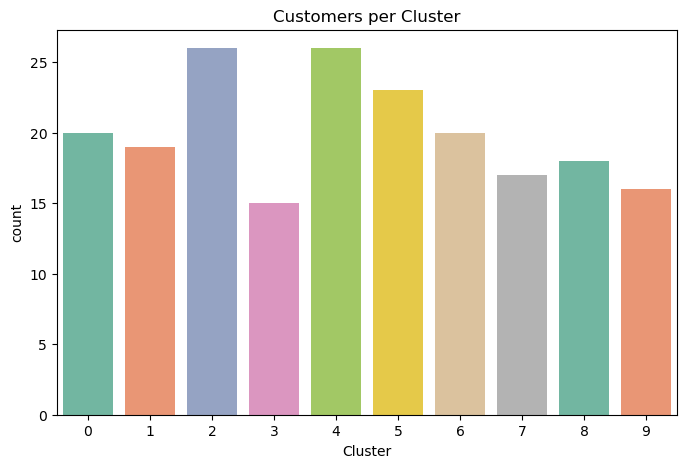

In [12]:

# -----------------------------
# CLUSTER PROFILE
# -----------------------------
print("\n")
print("="*60)
print("CLUSTER PROFILE")
print("="*60)

cluster_profile = df.groupby("Cluster").mean(numeric_only=True)

display(cluster_profile)

# Cluster Size
print("\nCluster Sizes:")
display(df["Cluster"].value_counts().sort_index())

plt.figure(figsize=(8,5))
sns.countplot(x="Cluster", data=df, palette="Set2")
plt.title("Customers per Cluster")
plt.show()


In [13]:

# -----------------------------
# MARKETING STRATEGIES
# -----------------------------
print("\n")
print("="*60)
print("MARKETING STRATEGIES")
print("="*60)

for cluster in sorted(df['Cluster'].unique()):

    segment = df[df['Cluster']==cluster]

    avg_income = segment['Annual Income (k$)'].mean()
    avg_spending = segment['Spending Score (1-100)'].mean()
    avg_age = segment['Age'].mean()

    print(f"\nCluster {cluster}")
    print("-"*40)

    print(f"Average Age: {avg_age:.1f}")
    print(f"Average Income: {avg_income:.1f}")
    print(f"Average Spending Score: {avg_spending:.1f}")

    if avg_income >= 70 and avg_spending >= 60:
        print("Segment Type: High Income - High Spending")
        print("Strategy:")
        print("• VIP membership programs")
        print("• Premium product recommendations")
        print("• Exclusive events and loyalty rewards")

    elif avg_income >= 70 and avg_spending < 60:
        print("Segment Type: High Income - Low Spending")
        print("Strategy:")
        print("• Personalized promotions")
        print("• Targeted luxury product campaigns")
        print("• Special discounts to increase engagement")

    elif avg_income < 70 and avg_spending >= 60:
        print("Segment Type: Low Income - High Spending")
        print("Strategy:")
        print("• Budget-friendly bundles")
        print("• Seasonal offers")
        print("• Cashback and reward programs")

    else:
        print("Segment Type: Low Income - Low Spending")
        print("Strategy:")
        print("• Mass marketing campaigns")
        print("• Discount coupons")
        print("• Awareness and engagement campaigns")

print("\n")
print("="*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*60)



MARKETING STRATEGIES

Cluster 0
----------------------------------------
Average Age: 28.1
Average Income: 49.7
Average Spending Score: 69.1
Segment Type: Low Income - High Spending
Strategy:
• Budget-friendly bundles
• Seasonal offers
• Cashback and reward programs

Cluster 1
----------------------------------------
Average Age: 46.9
Average Income: 45.5
Average Spending Score: 37.4
Segment Type: Low Income - Low Spending
Strategy:
• Mass marketing campaigns
• Discount coupons
• Awareness and engagement campaigns

Cluster 2
----------------------------------------
Average Age: 31.2
Average Income: 51.5
Average Spending Score: 47.4
Segment Type: Low Income - Low Spending
Strategy:
• Mass marketing campaigns
• Discount coupons
• Awareness and engagement campaigns

Cluster 3
----------------------------------------
Average Age: 42.3
Average Income: 88.7
Average Spending Score: 12.2
Segment Type: High Income - Low Spending
Strategy:
• Personalized promotions
• Targeted luxury product ca